# BTCUSDT 1D — Descarga, features y CSV (MVP)

Objetivo:
- Descargar OHLCV diarios de Binance (BTCUSDT).
- Calcular derivados mínimos (log_close, log_return) y medias móviles (SMA/EMA).
- Guardar un CSV reproducible para entrenamiento y análisis.
- Generar gráficas para el reporte.

In [2]:
import sys, subprocess, importlib
for p in ["pandas","numpy","matplotlib","requests"]:
    try:
        importlib.import_module(p)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import time
import pathlib
from datetime import datetime, timezone

## Parámetros

In [4]:
symbol = "BTCUSDT"
interval = "1d"
start_date = "2017-08-18"
end_date = None
base_dir = pathlib.Path(".").resolve()
data_dir = (base_dir.parent / "data").resolve()
data_dir.mkdir(parents=True, exist_ok=True)
csv_path = data_dir / "btc_binance_ohlcv_1d.csv"
csv_path

PosixPath('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/data/btc_binance_ohlcv_1d.csv')

## Descarga desde Binance

In [6]:
def to_ms(date_str):
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)

def fetch_klines(symbol, interval, start_time_ms, end_time_ms=None, limit=1000, pause=0.2):
    url = "https://api.binance.com/api/v3/klines"
    all_rows = []
    current = start_time_ms
    while True:
        params = {"symbol": symbol, "interval": interval, "limit": limit, "startTime": current}
        if end_time_ms is not None:
            params["endTime"] = end_time_ms
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        rows = r.json()
        if not rows:
            break
        all_rows.extend(rows)
        last_open = rows[-1][0]
        next_start = last_open + 1
        if end_time_ms is not None and next_start > end_time_ms:
            break
        if len(rows) < limit:
            break
        current = next_start
        time.sleep(pause)
    cols = [
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","num_trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ]
    df = pd.DataFrame(all_rows, columns=cols)
    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df = df[["timestamp","open","high","low","close","volume"]]
    df = df.sort_values("timestamp").drop_duplicates("timestamp", keep="last").reset_index(drop=True)
    return df

start_ms = to_ms(start_date)
end_ms = None if end_date is None else to_ms(end_date)
df = fetch_klines(symbol, interval, start_ms, end_ms)
df.shape

(3113, 6)

## Cálculo de derivados y medias móviles

In [7]:
df["log_close"] = np.log(df["close"])
df["log_return"] = df["log_close"].diff()
for n in [8,20,100,200]:
    df[f"sma_{n}"] = df["close"].rolling(n, min_periods=n).mean()
    df[f"ema_{n}"] = df["close"].ewm(span=n, adjust=False).mean()
df["volatility_7"] = df["log_return"].rolling(7, min_periods=7).std()
df.tail()

,timestamp,open,high,low,close,volume,log_close,log_return,sma_8,ema_8,sma_20,ema_20,sma_100,ema_100,sma_200,ema_200,volatility_7
3108,2026-02-20 00:00:00+00:00,67003.73,68318.39,66280.20,68020.01,35351.87091,11.127557,0.015054,68173.77250,68022.847509,69773.8450,71313.751203,85935.4883,85932.881792,99409.06715,92840.986592,0.014881
3109,2026-02-21 00:00:00+00:00,68020.00,68698.70,67534.69,67975.93,8032.84131,11.126909,-0.000648,68064.01875,68012.421396,69324.2310,70995.863469,85618.3274,85577.298589,99178.29805,92593.573093,0.013244
3110,2026-02-22 00:00:00+00:00,67975.93,68245.00,67190.00,67643.40,8175.13484,11.122005,-0.004904,67791.57500,67930.416641,68769.4705,70676.581234,85348.8214,85222.171884,98941.55370,92345.312664,0.012461
3111,2026-02-23 00:00:00+00:00,67643.39,67684.86,63888.79,64656.02,33075.90923,11.076836,-0.045169,67269.50500,67202.772943,68213.7610,70103.194450,85039.4192,84814.921352,98677.47375,92069.797315,0.020162
3112,2026-02-24 00:00:00+00:00,64656.01,65026.75,62700.80,63023.44,12629.26110,11.051262,-0.025574,66535.88125,66274.032289,67706.6415,69428.932121,84727.0392,84383.406869,98409.21725,91780.778834,0.020737


## Guardado a CSV

In [8]:
df.to_csv(csv_path, index=False)

## Chequeos rápidos

In [18]:
df.head()

,timestamp,open,high,low,close,volume,log_close,log_return,sma_8,ema_8,sma_20,ema_20,sma_100,ema_100,sma_200,ema_200,volatility_7
0,2017-08-18 00:00:00+00:00,4285.08,4371.52,3938.77,4108.37,1199.888264,8.320782,NaN,NaN,4108.370000,NaN,4108.370000,NaN,4108.370000,NaN,4108.370000,NaN
1,2017-08-19 00:00:00+00:00,4108.37,4184.69,3850.00,4139.98,381.309763,8.328446,0.007665,NaN,4115.394444,NaN,4111.380476,NaN,4108.995941,NaN,4108.684527,NaN
2,2017-08-20 00:00:00+00:00,4120.98,4211.08,4032.62,4086.29,467.083022,8.315393,-0.013053,NaN,4108.926790,NaN,4108.990907,NaN,4108.546318,NaN,4108.461696,NaN
3,2017-08-21 00:00:00+00:00,4069.13,4119.62,3911.79,4016.00,691.743060,8.298042,-0.017351,NaN,4088.276392,NaN,4100.134630,NaN,4106.713718,NaN,4107.541679,NaN
4,2017-08-22 00:00:00+00:00,4016.00,4104.82,3400.00,4040.00,966.684858,8.304000,0.005958,NaN,4077.548305,NaN,4094.407523,NaN,4105.392654,NaN,4106.869623,NaN


In [19]:
df.isna().sum()

timestamp         0
open              0
high              0
low               0
close             0
volume            0
log_close         0
log_return        1
sma_8             7
ema_8             0
sma_20           19
ema_20            0
sma_100          99
ema_100           0
sma_200         199
ema_200           0
volatility_7      7
dtype: int64

## Gráficas para el reporte

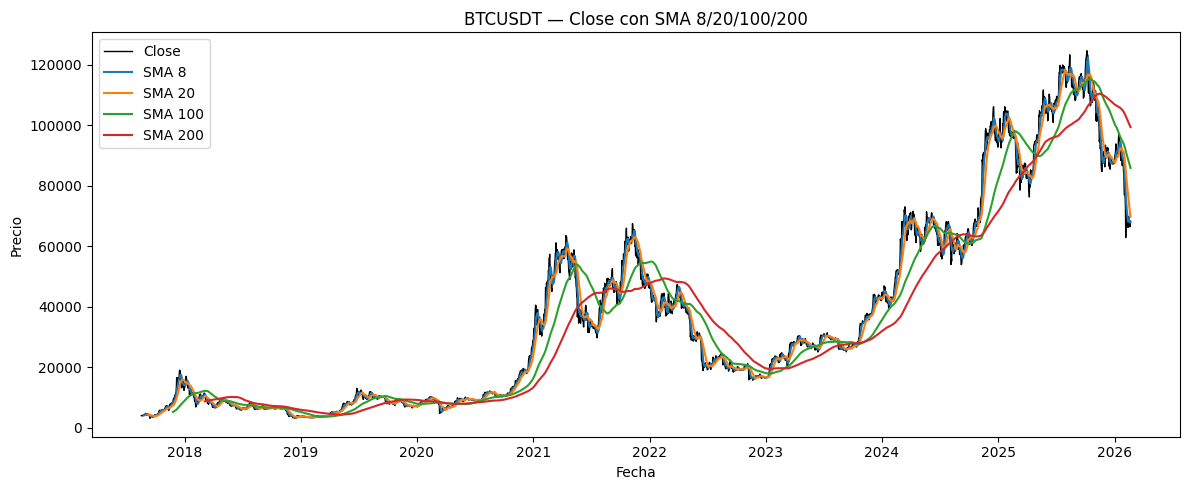

In [20]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["timestamp"], df["close"], label="Close", color="black", linewidth=1)
ax.plot(df["timestamp"], df["sma_8"], label="SMA 8")
ax.plot(df["timestamp"], df["sma_20"], label="SMA 20")
ax.plot(df["timestamp"], df["sma_100"], label="SMA 100")
ax.plot(df["timestamp"], df["sma_200"], label="SMA 200")
ax.set_title("BTCUSDT — Close con SMA 8/20/100/200")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()
plt.tight_layout()
plt.show()

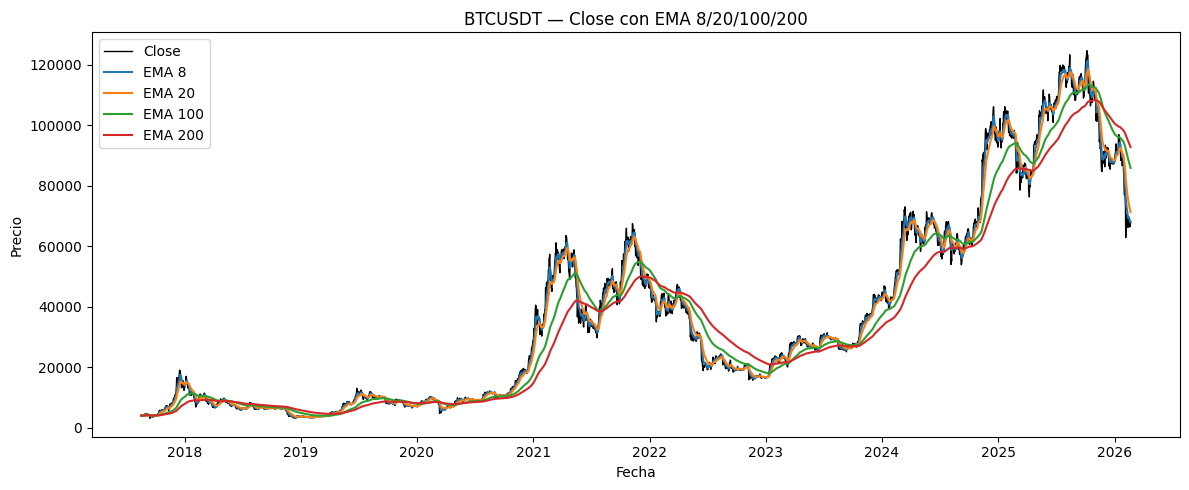

In [21]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["timestamp"], df["close"], label="Close", color="black", linewidth=1)
ax.plot(df["timestamp"], df["ema_8"], label="EMA 8")
ax.plot(df["timestamp"], df["ema_20"], label="EMA 20")
ax.plot(df["timestamp"], df["ema_100"], label="EMA 100")
ax.plot(df["timestamp"], df["ema_200"], label="EMA 200")
ax.set_title("BTCUSDT — Close con EMA 8/20/100/200")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()
plt.tight_layout()
plt.show()

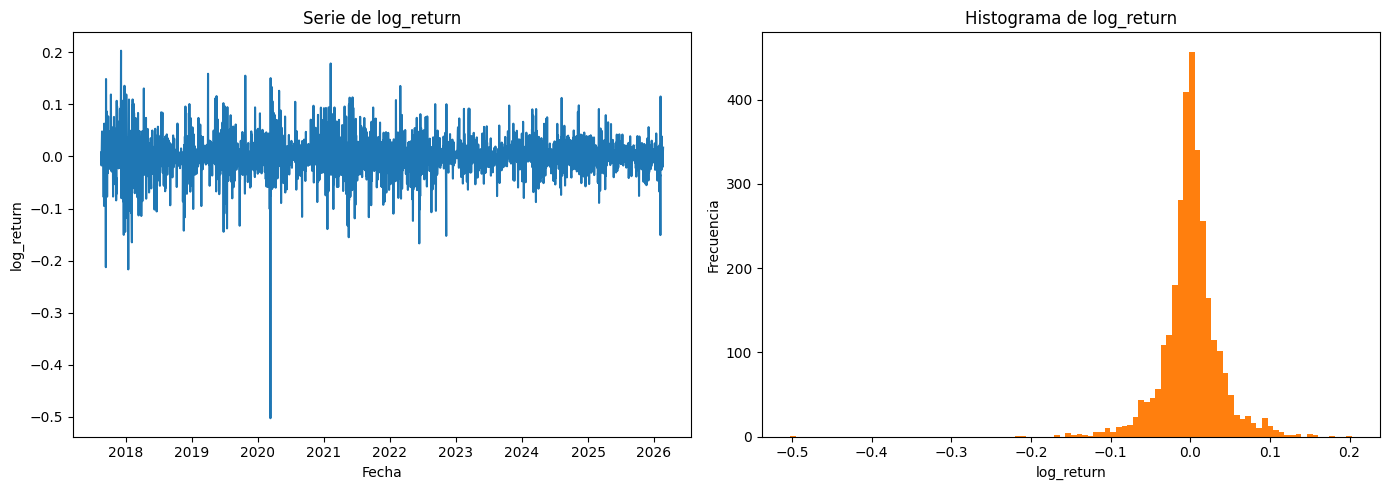

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(df["timestamp"], df["log_return"], color="tab:blue")
axes[0].set_title("Serie de log_return")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("log_return")
axes[1].hist(df["log_return"].dropna(), bins=100, color="tab:orange")
axes[1].set_title("Histograma de log_return")
axes[1].set_xlabel("log_return")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

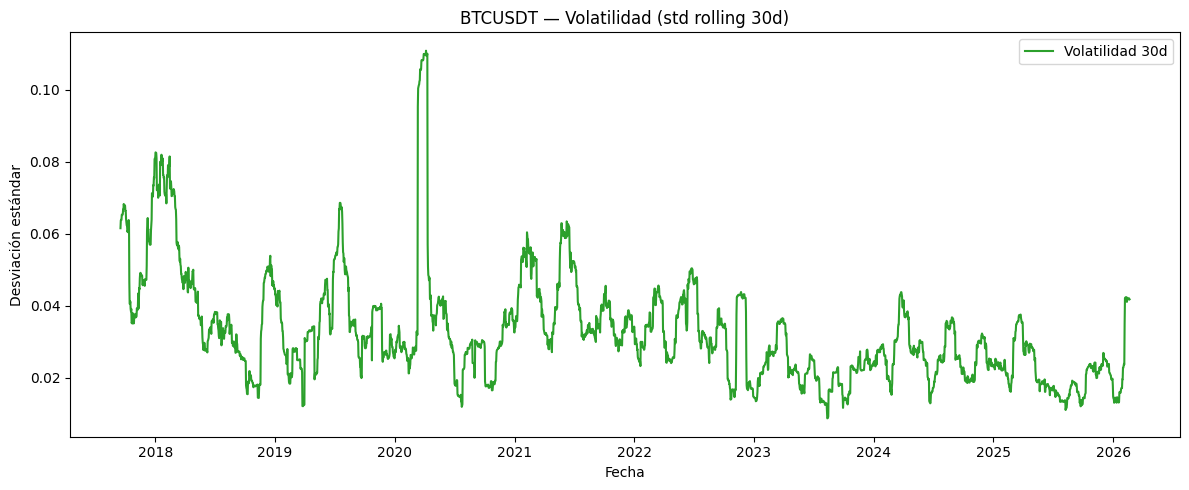

In [23]:
vol30 = df["log_return"].rolling(30, min_periods=30).std()
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["timestamp"], vol30, label="Volatilidad 30d", color="tab:green")
ax.set_title("BTCUSDT — Volatilidad (std rolling 30d)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Desviación estándar")
ax.legend()
plt.tight_layout()
plt.show()

## Exportar figuras a PNG\n
Las figuras se guardan en `backend/figures/` con alta resolución.

In [24]:
figures_dir = (base_dir.parent / "figures").resolve()
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["timestamp"], df["close"], label="Close", color="black", linewidth=1)
ax.plot(df["timestamp"], df["sma_8"], label="SMA 8")
ax.plot(df["timestamp"], df["sma_20"], label="SMA 20")
ax.plot(df["timestamp"], df["sma_100"], label="SMA 100")
ax.plot(df["timestamp"], df["sma_200"], label="SMA 200")
ax.set_title("BTCUSDT — Close con SMA 8/20/100/200")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()
plt.tight_layout()
fig.savefig(figures_dir / "BTC_close_with_SMA_8_20_100_200.png", dpi=300, bbox_inches='tight')
plt.close(fig)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["timestamp"], df["close"], label="Close", color="black", linewidth=1)
ax.plot(df["timestamp"], df["ema_8"], label="EMA 8")
ax.plot(df["timestamp"], df["ema_20"], label="EMA 20")
ax.plot(df["timestamp"], df["ema_100"], label="EMA 100")
ax.plot(df["timestamp"], df["ema_200"], label="EMA 200")
ax.set_title("BTCUSDT — Close con EMA 8/20/100/200")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()
plt.tight_layout()
fig.savefig(figures_dir / "BTC_close_with_EMA_8_20_100_200.png", dpi=300, bbox_inches='tight')
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(df["timestamp"], df["log_return"], color="tab:blue")
axes[0].set_title("Serie de log_return")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("log_return")
axes[1].hist(df["log_return"].dropna(), bins=100, color="tab:orange")
axes[1].set_title("Histograma de log_return")
axes[1].set_xlabel("log_return")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
fig.savefig(figures_dir / "BTC_log_return_series_hist.png", dpi=300, bbox_inches='tight')
plt.close(fig)

vol30 = df["log_return"].rolling(30, min_periods=30).std()
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["timestamp"], vol30, label="Volatilidad 30d", color="tab:green")
ax.set_title("BTCUSDT — Volatilidad (std rolling 30d)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Desviación estándar")
ax.legend()
plt.tight_layout()
fig.savefig(figures_dir / "BTC_volatility_30d.png", dpi=300, bbox_inches='tight')
plt.close(fig)

[str(figures_dir / f) for f in ["BTC_close_with_SMA_8_20_100_200.png", "BTC_close_with_EMA_8_20_100_200.png", "BTC_log_return_series_hist.png", "BTC_volatility_30d.png"]]


['/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/backend/figures/BTC_close_with_SMA_8_20_100_200.png',
 '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/backend/figures/BTC_close_with_EMA_8_20_100_200.png',
 '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/backend/figures/BTC_log_return_series_hist.png',
 '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/btc-forecast/backend/figures/BTC_volatility_30d.png']

In [ ]:
ma_window = 30

d = df.copy()
d["trend"] = d["close"].rolling(ma_window, min_periods=ma_window).mean()
d = d.dropna(subset=["trend"]).copy()
d["detrended_index"] = d["close"] - d["trend"]
d["detrended_return"] = d["detrended_index"].diff()

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, gridspec_kw={"hspace": 0.15})

axes[0].plot(d["timestamp"], d["close"], label=r"$I(t)$", color="tab:blue", linewidth=1)
axes[0].plot(d["timestamp"], d["trend"], label=f"$\\bar{{I}}(t)$ (MA {ma_window}d)", color="tab:red", linewidth=1)
axes[0].set_ylabel(r"$I(t)$")
axes[0].set_title("(a) Trended price index")
axes[0].legend(loc="upper right")

axes[1].plot(d["timestamp"], d["detrended_index"], color="tab:blue", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.7, alpha=0.6)
axes[1].set_ylabel(r"$\hat{I}(t)$")
axes[1].set_title("(b) Detrended price index")

axes[2].plot(d["timestamp"], d["detrended_return"], color="tab:blue", linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=0.7, alpha=0.6)
axes[2].set_ylabel(r"$x^*(t)$")
axes[2].set_xlabel("time")
axes[2].set_title("(c) Detrended price return")

out_dir = (base_dir.parent / "figuras" / "marco_teorico").resolve()
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "fig_3_7_detrending_analysis_period2.png"
fig.suptitle(f"BTCUSDT — Detrending analysis (MA {ma_window}d)")
fig.subplots_adjust(top=0.92)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.close(fig)
str(out_path)